# PiXTime Benchmark Dashboard

This notebook provides a comprehensive, visual comparison of **5 time-series forecasting models** across multiple datasets and prediction horizons using results stored under `evaluation/`.

### Models Compared
| Model | Description |
|---|---|
| **DLinear** | Decomposition-based linear model |
| **iTransformer** | Inverted-dimension Transformer |
| **PatchTST** | Patch-based Transformer for time series |
| **TimeXer** | Exogenous-aware Transformer |
| **PiXTime** | Proposed model (pixel-time fusion) |

### Datasets & Metrics
- **Datasets**: ETT family (ETTh1, ETTh2, ETTm1) — standard long-term forecasting benchmarks
- **Prediction horizons**: 96, 192, 336, 720 steps ahead
- **Metrics**: MSE (Mean Squared Error) and MAE (Mean Absolute Error) — lower is better for both

---
*Plots are generated automatically from available `.txt` result files. Missing experiments are shown in the coverage matrix.*

In [1]:
# Core imports
from pathlib import Path
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# Notebook display
from IPython.display import display

# ── Aesthetic theme ──────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.title_fontsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
    'grid.color': 'white',
    'grid.linewidth': 1.2,
})

MODEL_ORDER = ['DLinear', 'iTransformer', 'PatchTST', 'TimeXer', 'PiXTime']

# Colorblind-friendly palette; PiXTime uses a vivid accent to stand out
MODEL_COLORS = {
    'DLinear':      '#4477AA',   # blue
    'iTransformer': '#EE6677',   # rose
    'PatchTST':     '#228833',   # green
    'TimeXer':      '#CCBB44',   # yellow-olive
    'PiXTime':      '#AA3377',   # magenta accent
}

MARKER_STYLES = {
    'DLinear':      'o',
    'iTransformer': 's',
    'PatchTST':     '^',
    'TimeXer':      'D',
    'PiXTime':      '*',
}

print('Libraries loaded.')

Libraries loaded.


In [2]:
EVAL_ROOT = Path('evaluation')
assert EVAL_ROOT.exists(), f'Missing evaluation directory: {EVAL_ROOT.resolve()}'

# Example file name pattern:
# DLinearETTh1PatL16PreL96FeaMDM512ED2048DD2048EL2DL2.txt
name_pattern = re.compile(
    r'^(?P<model>DLinear|iTransformer|PatchTST|TimeXer|PiXTime)'
    r'(?P<dataset>.+?)PatL(?P<patch_len>\d+)'
    r'PreL(?P<pred_len>\d+)Fea(?P<features>[A-Za-z]+)'
    r'DM(?P<d_model>\d+)ED(?P<en_d_ff>\d+)DD(?P<de_d_ff>\d+)'
    r'EL(?P<en_layers>\d+)DL(?P<de_layers>\d+)$'
)

metric_pattern = re.compile(r'mse:(?P<mse>[-+eE0-9.]+),\s*mae:(?P<mae>[-+eE0-9.]+)')

rows = []
for txt_file in sorted(EVAL_ROOT.glob('*/*.txt')):
    model_dir = txt_file.parent.name
    stem = txt_file.stem

    m = name_pattern.match(stem)
    if not m:
        continue

    text = txt_file.read_text(encoding='utf-8', errors='ignore')
    metric_hits = list(metric_pattern.finditer(text))
    if not metric_hits:
        continue

    # Use the latest logged metrics if file has multiple runs appended
    last_metrics = metric_hits[-1].groupdict()
    info = m.groupdict()

    rows.append({
        'file_path': str(txt_file),
        'model': info['model'],
        'model_dir': model_dir,
        'dataset': info['dataset'],
        'patch_len': int(info['patch_len']),
        'pred_len': int(info['pred_len']),
        'features': info['features'],
        'd_model': int(info['d_model']),
        'en_d_ff': int(info['en_d_ff']),
        'de_d_ff': int(info['de_d_ff']),
        'en_layers': int(info['en_layers']),
        'de_layers': int(info['de_layers']),
        'mse': float(last_metrics['mse']),
        'mae': float(last_metrics['mae']),
        'num_logged_runs': len(metric_hits)
    })

df = pd.DataFrame(rows)

if df.empty:
    raise ValueError('No valid evaluation files found in evaluation/*/*.txt')

# Consistent ordering for plots
available_models = [m for m in MODEL_ORDER if m in set(df['model'])]
if len(available_models) < len(set(df['model'])):
    remaining = sorted(set(df['model']) - set(available_models))
    available_models += remaining

df['model'] = pd.Categorical(df['model'], categories=available_models, ordered=True)
df = df.sort_values(['dataset', 'pred_len', 'model']).reset_index(drop=True)

print(f'Loaded {len(df)} experiment records.')
display(df.head(10))

Loaded 28 experiment records.


,file_path,model,model_dir,dataset,patch_len,pred_len,features,d_model,en_d_ff,de_d_ff,en_layers,de_layers,mse,mae,num_logged_runs
0,evaluation/DLinear/DLinearETTh1PatL16PreL96Fea...,DLinear,DLinear,ETTh1,16,96,M,512,2048,2048,2,2,0.395856,0.410441,3
1,evaluation/iTransformer/iTransformerETTh1PatL1...,iTransformer,iTransformer,ETTh1,16,96,M,128,128,2048,2,2,0.393244,0.408622,3
2,evaluation/PatchTST/PatchTSTETTh1PatL16PreL96F...,PatchTST,PatchTST,ETTh1,16,96,M,512,2048,2048,1,2,0.381651,0.399799,3
3,evaluation/TimeXer/TimeXerETTh1PatL16PreL96Fea...,TimeXer,TimeXer,ETTh1,16,96,M,256,2048,2048,1,2,0.386127,0.398560,2
4,evaluation/PiXTime/PiXTimeETTh1PatL16PreL96Fea...,PiXTime,PiXTime,ETTh1,16,96,M,512,2048,2048,1,1,0.373925,0.393385,2
5,evaluation/DLinear/DLinearETTh1PatL16PreL192Fe...,DLinear,DLinear,ETTh1,16,192,M,512,2048,2048,2,2,0.444660,0.440053,3
6,evaluation/iTransformer/iTransformerETTh1PatL1...,iTransformer,iTransformer,ETTh1,16,192,M,128,128,2048,2,2,0.450512,0.442640,3
7,evaluation/PatchTST/PatchTSTETTh1PatL16PreL192...,PatchTST,PatchTST,ETTh1,16,192,M,512,2048,2048,1,2,0.430234,0.434259,2
8,evaluation/TimeXer/TimeXerETTh1PatL16PreL192Fe...,TimeXer,TimeXer,ETTh1,16,192,M,128,2048,2048,2,2,0.438647,0.430380,2
9,evaluation/PiXTime/PiXTimeETTh1PatL16PreL192Fe...,PiXTime,PiXTime,ETTh1,16,192,M,512,2048,2048,1,1,0.419459,0.422706,2


In [3]:
datasets   = sorted(df['dataset'].unique())
pred_lens  = sorted(df['pred_len'].unique())
models     = [m for m in df['model'].cat.categories if m in set(df['model'])]

summary = pd.DataFrame({
    'Records':        [len(df)],
    'Models':         [df['model'].nunique()],
    'Datasets':       [df['dataset'].nunique()],
    'Pred horizons':  [df['pred_len'].nunique()],
    'Complete grid %': [f"{100*len(df)/(len(models)*len(datasets)*len(pred_lens)):.1f}%"]
})
display(summary)

# Build full coverage matrix
coverage = (
    df.groupby(['dataset', 'pred_len', 'model'], observed=True)
      .size().rename('count').reset_index()
)
full_index = pd.MultiIndex.from_product(
    [datasets, pred_lens, models], names=['dataset', 'pred_len', 'model']
)
coverage_full = (
    coverage.set_index(['dataset', 'pred_len', 'model'])
            .reindex(full_index, fill_value=0)
            .reset_index()
)
missing = coverage_full[coverage_full['count'] == 0].copy()
print(f'Missing combinations: {len(missing)} / {len(full_index)}')

,Records,Models,Datasets,Pred horizons,Complete grid %
0,28,5,3,4,46.7%


Missing combinations: 32 / 60


---
## 1 — Benchmark Coverage Matrix

**What this shows:** Which `(dataset, prediction-horizon, model)` combinations have a logged result.  
A cell value of **1** means the experiment ran and produced metrics; **0** means the result file is missing.

**Why it matters:** Any missing cell introduces a gap in later comparisons. Models that ran fewer experiments may look artificially better or worse when averages are taken. Use this matrix to know how much weight to give the aggregate rankings below.

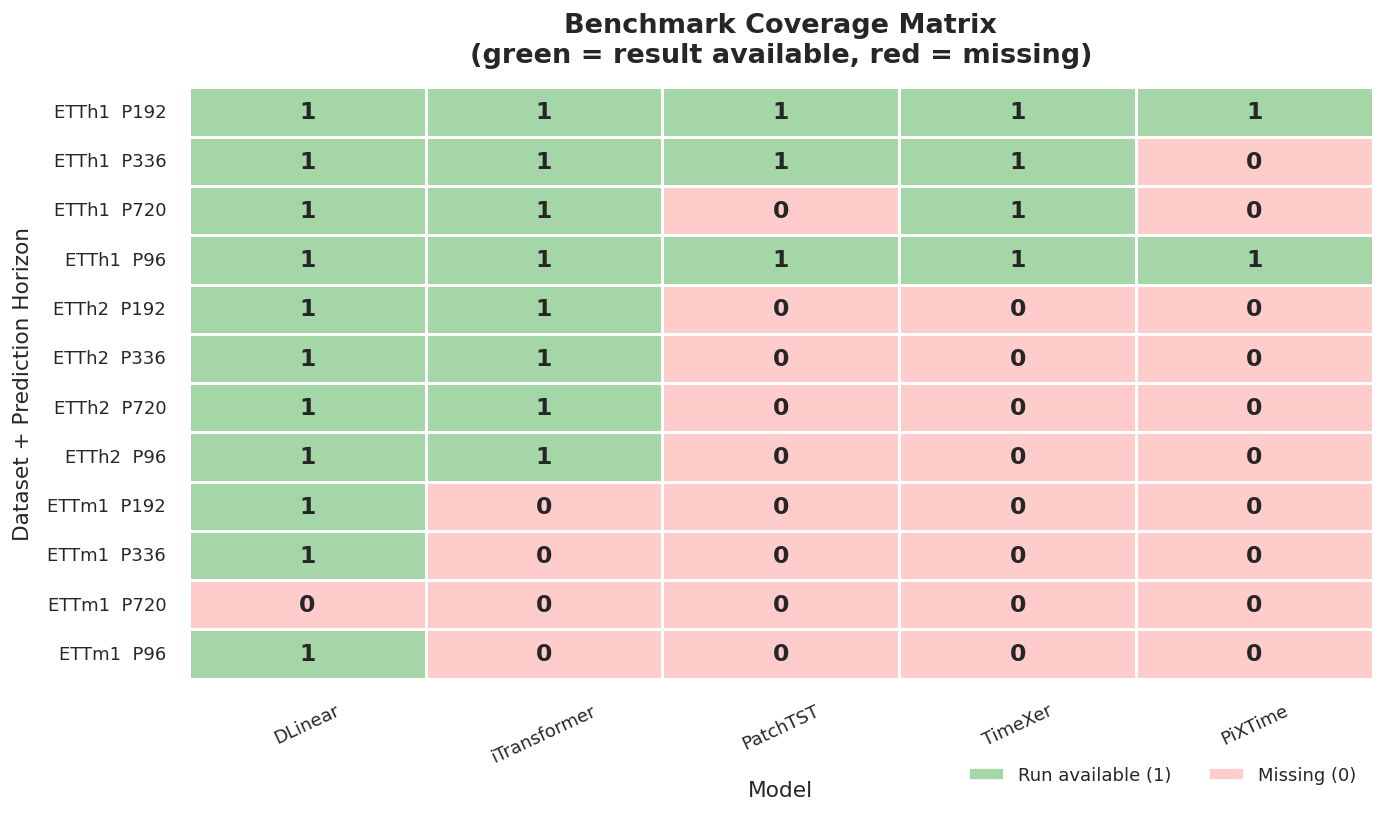

Coverage: 28/60 cells filled (46.7%)


In [4]:
coverage_heat = (
    coverage_full
    .assign(dataset_pred=lambda x: x['dataset'] + '  P' + x['pred_len'].astype(str))
    .pivot_table(index='dataset_pred', columns='model', values='count', fill_value=0)
)
# Reorder columns
heat_cols = [m for m in MODEL_ORDER if m in coverage_heat.columns]
coverage_heat = coverage_heat[heat_cols]

fig, ax = plt.subplots(figsize=(11, max(5, 0.55 * len(coverage_heat))))
cmap = sns.color_palette(['#FFCCCC', '#C8E6C9'], as_cmap=False)
from matplotlib.colors import ListedColormap
binary_cmap = ListedColormap(['#FFCCCC', '#A5D6A7'])

sns.heatmap(
    coverage_heat,
    ax=ax,
    cmap=binary_cmap,
    linewidths=0.6,
    linecolor='white',
    cbar=False,
    annot=True,
    fmt='.0f',
    annot_kws={'size': 13, 'weight': 'bold'},
    vmin=0, vmax=1,
)
ax.set_title('Benchmark Coverage Matrix\n(green = result available, red = missing)', pad=14)
ax.set_xlabel('Model', labelpad=8)
ax.set_ylabel('Dataset + Prediction Horizon', labelpad=8)
ax.tick_params(axis='x', rotation=25)
ax.tick_params(axis='y', rotation=0)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#A5D6A7', label='Run available (1)'),
                   Patch(facecolor='#FFCCCC', label='Missing (0)')]
ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.0, -0.12),
          ncol=2, frameon=False, fontsize=10)

plt.tight_layout()
plt.show()

total = len(coverage_full)
filled = (coverage_full['count'] > 0).sum()
print(f"Coverage: {filled}/{total} cells filled ({100*filled/total:.1f}%)")

---
## 2 — Direct Metric Comparison (MSE & MAE per Dataset × Horizon)

**What this shows:** Side-by-side grouped bar charts of **MSE** (left column) and **MAE** (right column) for each prediction horizon, broken out by dataset.  
Each group of bars represents all models that have a result for that `(dataset, horizon)` pair.

**How to read it:**
- **Shorter bars are better** — both MSE and MAE should be minimised.
- Compare bars of the same colour across datasets to see how a model generalises.
- Empty spots (no bar) indicate a missing experiment for that model.
- The annotated value on top of each bar is the exact metric score.

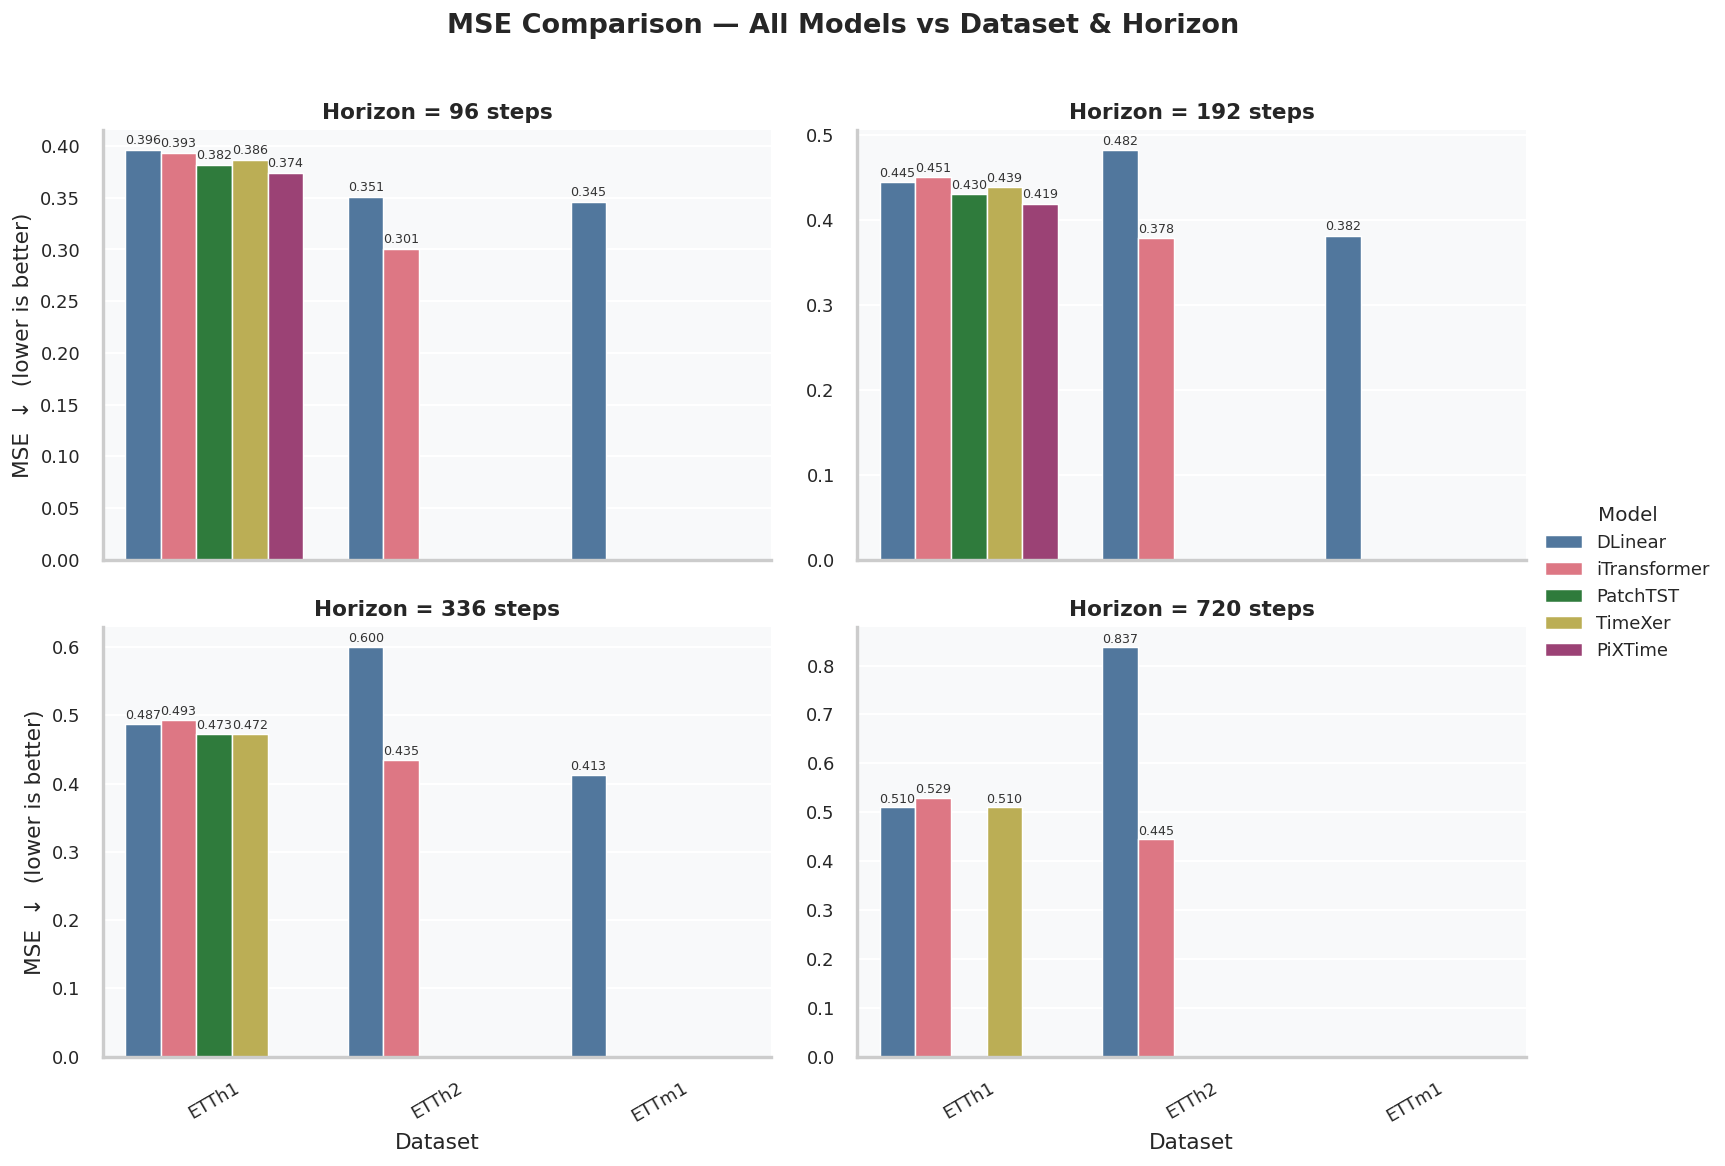

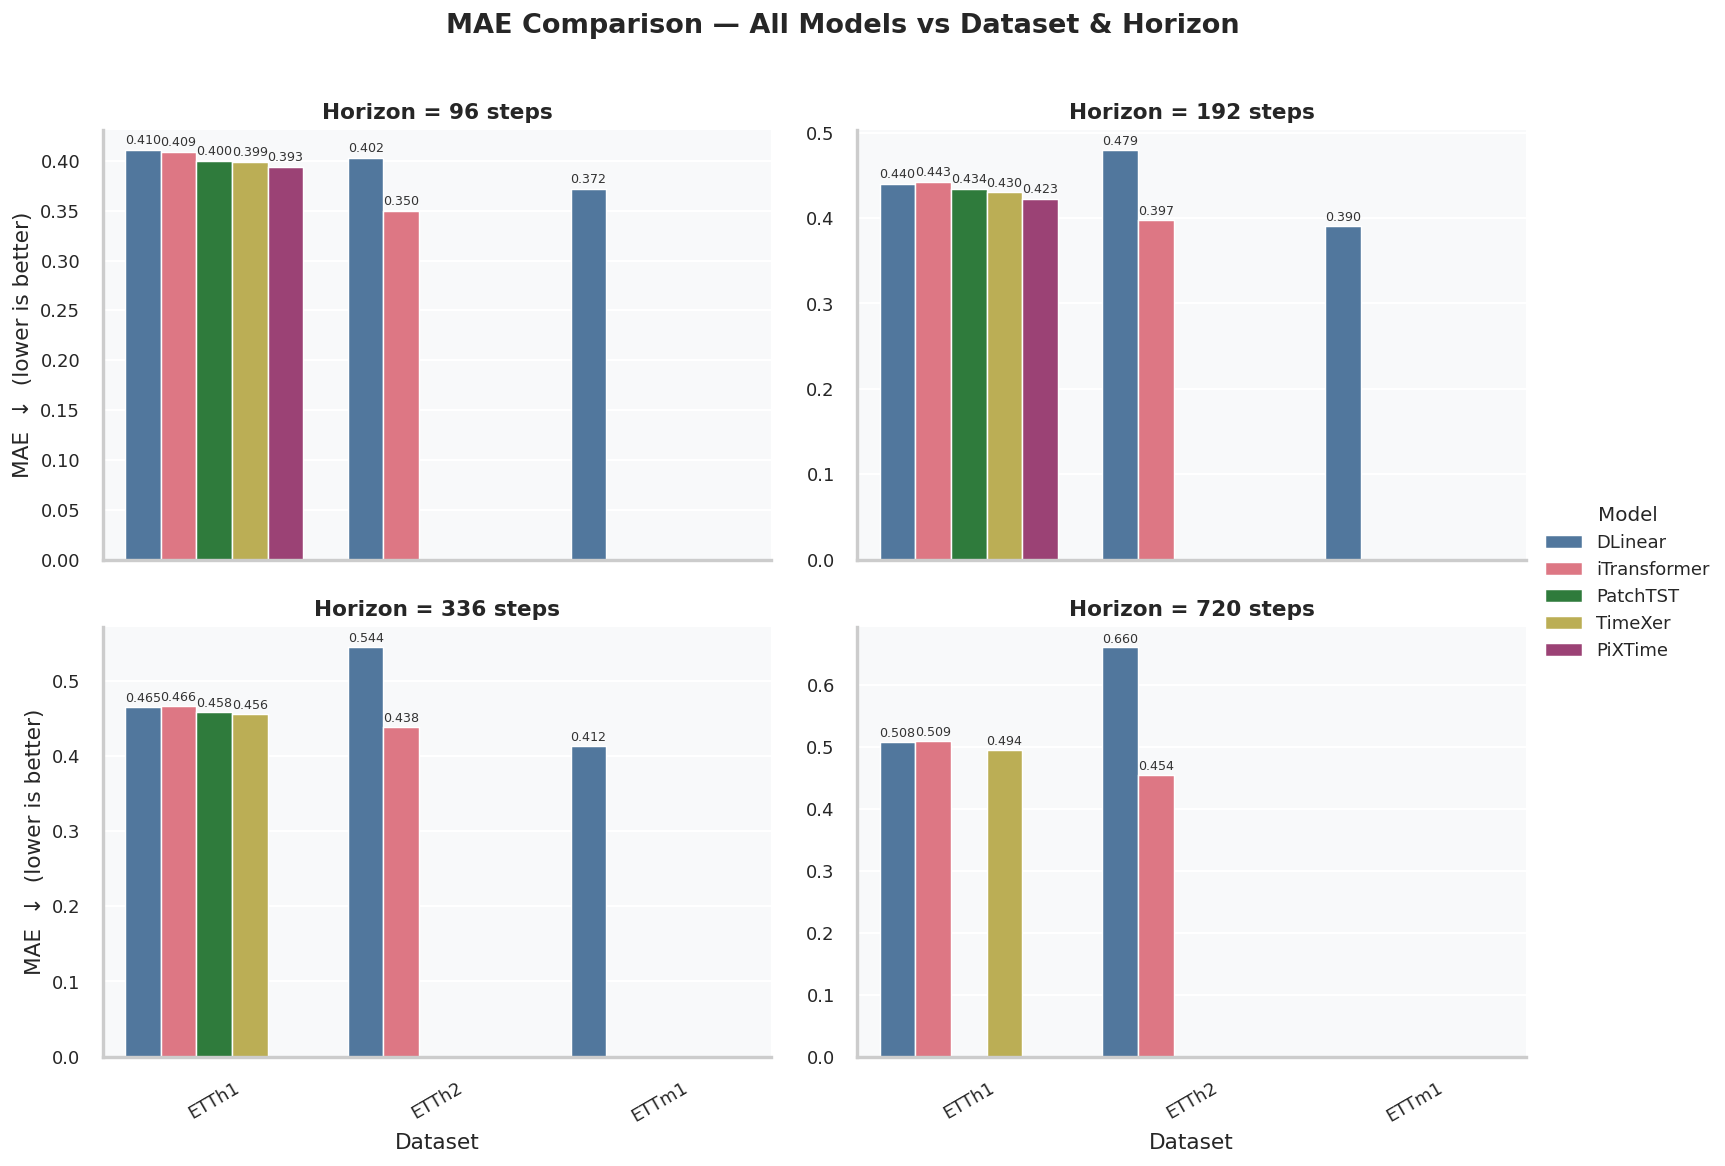

In [5]:
def annotated_catplot(metric, ylabel, title_prefix):
    """Return a FacetGrid catplot with value labels on each bar."""
    g = sns.catplot(
        data=df,
        kind='bar',
        x='dataset',
        y=metric,
        hue='model',
        col='pred_len',
        col_wrap=2,
        height=4.5,
        aspect=1.35,
        palette=MODEL_COLORS,
        order=sorted(df['dataset'].unique()),
        hue_order=models,
        sharey=False,
        edgecolor='white',
        linewidth=0.8,
    )
    g.set_titles(col_template='Horizon = {col_name} steps', size=12, fontweight='bold')
    g.set_axis_labels('Dataset', ylabel)
    g._legend.set_title('Model')

    # Rotate x labels and add value annotations
    for ax in g.axes.flatten():
        ax.tick_params(axis='x', rotation=30)
        for bar in ax.patches:
            h = bar.get_height()
            if np.isfinite(h) and h > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    h + 0.003,
                    f'{h:.3f}',
                    ha='center', va='bottom',
                    fontsize=7, color='#333333'
                )
        ax.set_facecolor('#F8F9FA')

    g.fig.subplots_adjust(top=0.88)
    g.fig.suptitle(f'{title_prefix} — All Models vs Dataset & Horizon',
                   fontsize=15, fontweight='bold')
    return g

g_mse = annotated_catplot('mse', 'MSE  ↓  (lower is better)', 'MSE Comparison')
plt.show()

g_mae = annotated_catplot('mae', 'MAE  ↓  (lower is better)', 'MAE Comparison')
plt.show()

---
## 3 — Metric Degradation vs Prediction Horizon

**What this shows:** How each model's MSE and MAE *grow* as the prediction horizon increases, faceted by dataset.  
Lines that stay flat indicate a model that degrades gracefully with longer horizons.

**How to read it:**
- **Steeper slope = worse horizon generalisation** — the model degrades quickly as it tries to forecast further ahead.
- Models at the **bottom** of the chart are better at each horizon.
- Each panel is one dataset so you can compare degradation behaviour per domain.
- Missing data points (gaps in a line) mean that experiment hasn't been run yet.

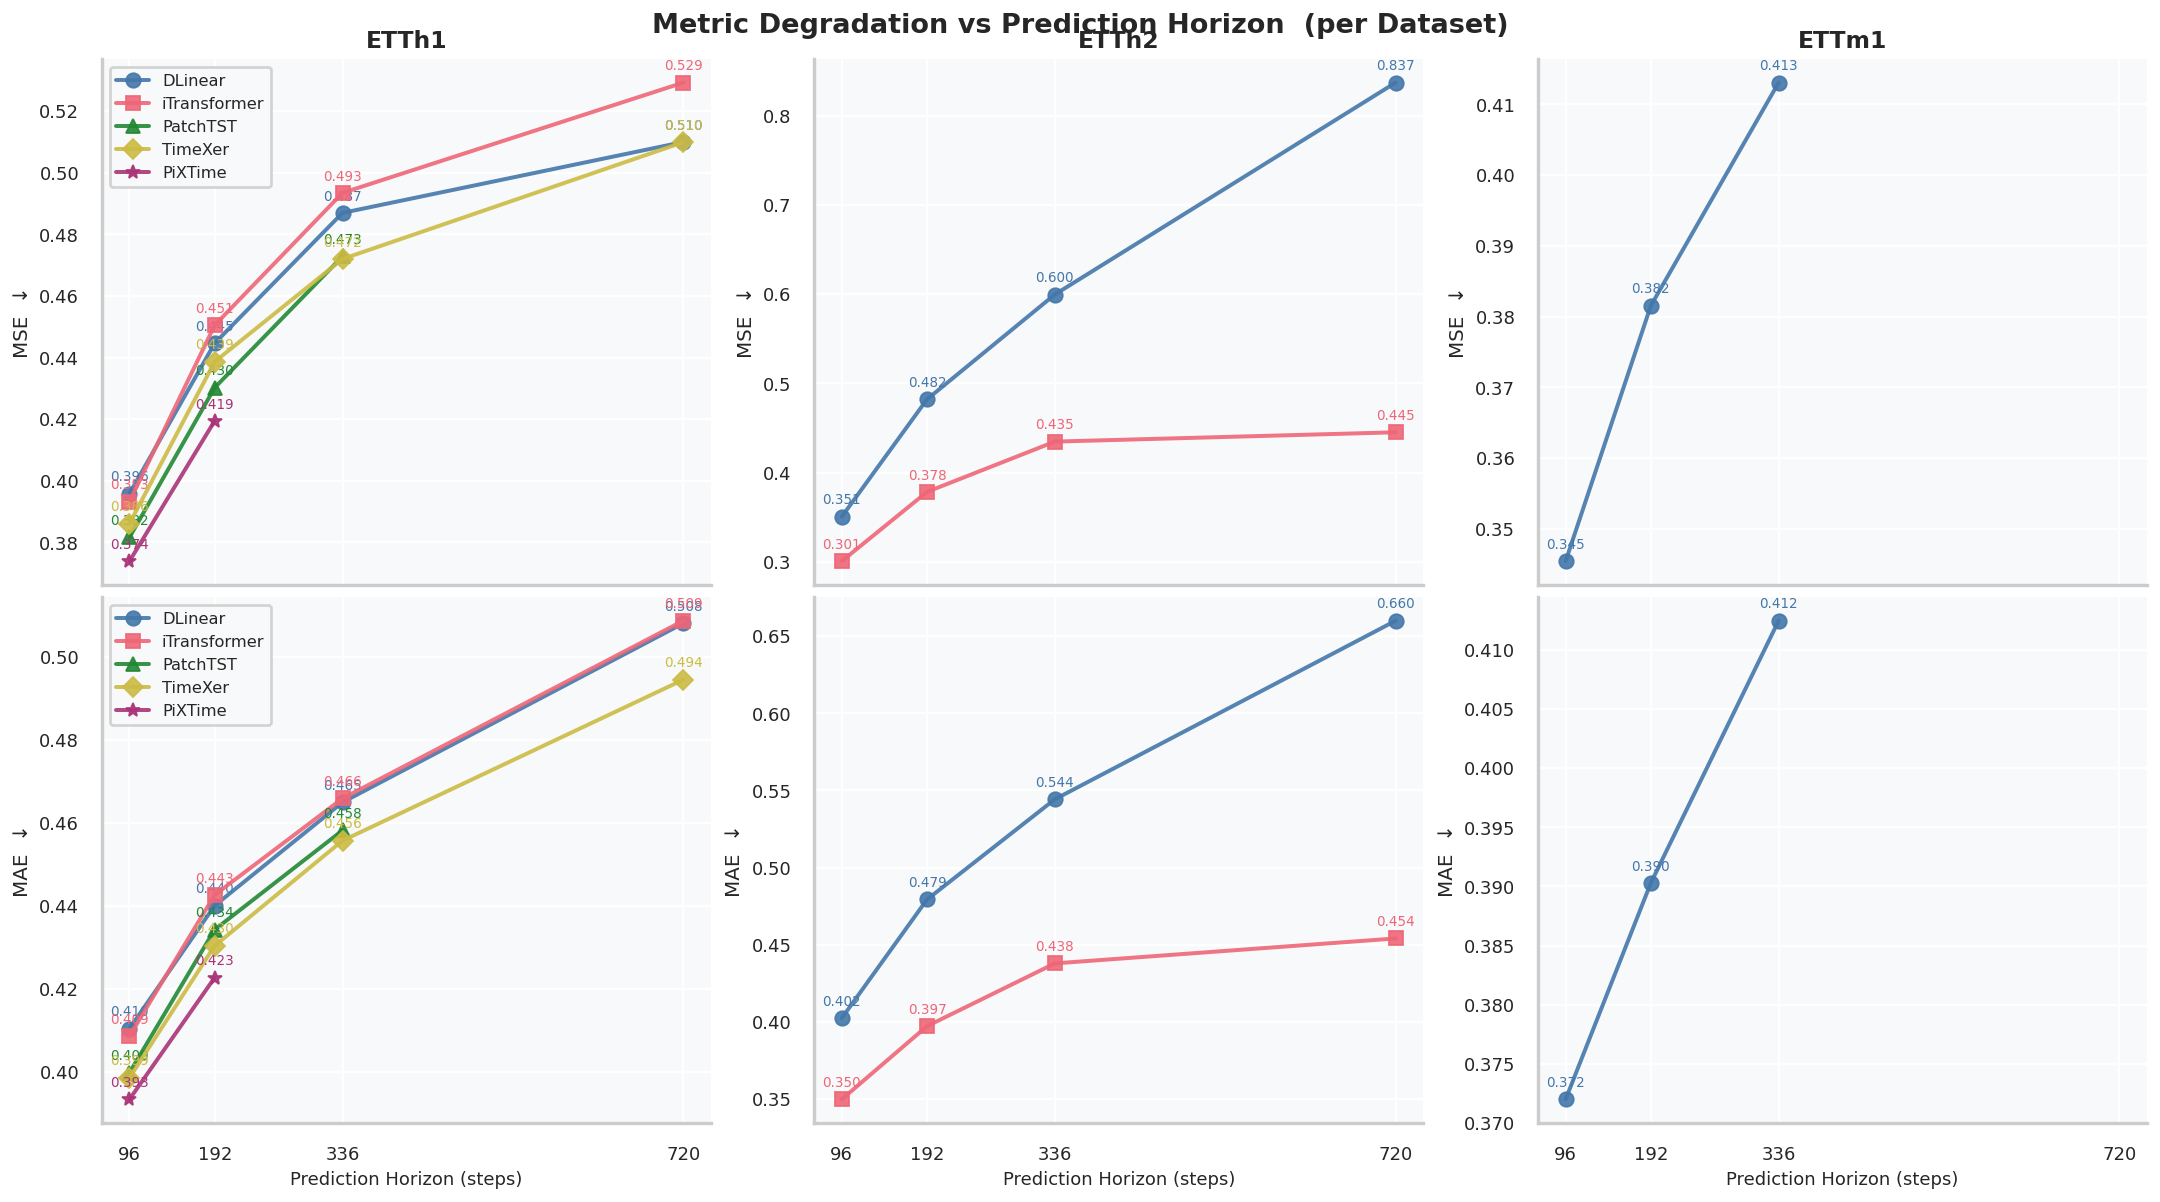

In [6]:
n_datasets = len(datasets)
fig, axes = plt.subplots(
    2, n_datasets,
    figsize=(5.5 * n_datasets, 9),
    sharex=True,
    constrained_layout=True,
)
if n_datasets == 1:
    axes = axes.reshape(2, 1)

for col_idx, dset in enumerate(sorted(datasets)):
    for row_idx, (metric, ylabel) in enumerate([('mse', 'MSE'), ('mae', 'MAE')]):
        ax = axes[row_idx, col_idx]
        sub = df[df['dataset'] == dset].copy()

        for model in models:
            mdf = sub[sub['model'] == model].sort_values('pred_len')
            if mdf.empty:
                continue
            color  = MODEL_COLORS.get(model, '#888888')
            marker = MARKER_STYLES.get(model, 'o')
            ax.plot(
                mdf['pred_len'], mdf[metric],
                marker=marker, markersize=8,
                linewidth=2.2, color=color,
                label=model, alpha=0.9,
                zorder=3,
            )
            # Annotate each point
            for _, row in mdf.iterrows():
                ax.annotate(
                    f"{row[metric]:.3f}",
                    (row['pred_len'], row[metric]),
                    textcoords='offset points', xytext=(0, 7),
                    ha='center', fontsize=7.5, color=color
                )

        ax.set_title(f'{dset}' if row_idx == 0 else '', fontsize=13, fontweight='bold', pad=6)
        ax.set_ylabel(f'{ylabel}  ↓', fontsize=11)
        ax.set_xlabel('Prediction Horizon (steps)' if row_idx == 1 else '', fontsize=10)
        ax.set_xticks(pred_lens)
        ax.set_facecolor('#F8F9FA')
        ax.grid(axis='y', color='white', linewidth=1.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if col_idx == 0:
            ax.legend(loc='upper left', framealpha=0.85, fontsize=9)

fig.suptitle('Metric Degradation vs Prediction Horizon  (per Dataset)',
             fontsize=15, fontweight='bold', y=1.01)
plt.show()

---
## 4 — Model Rank Heatmap (MSE & MAE)

**What this shows:** For each `(dataset, horizon)` pair where multiple models competed, each model is assigned a rank from **1 (best)** to **N (worst)**.  
The two heatmaps show ranks by MSE (left) and MAE (right) so you can see if the ordering is consistent across both metrics.

**How to read it:**
- **Dark green = Rank 1** (best model for that configuration).
- **Dark red = worst rank** for that configuration.
- A model that is consistently green across many rows is robustly the best.
- Grey cells (NaN) mean the model didn't run for that combination — it is excluded from ranking for that row.

/tmp/ipykernel_1277801/1926534486.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  rank_df.pivot_table(
/tmp/ipykernel_1277801/1926534486.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  rank_df.pivot_table(


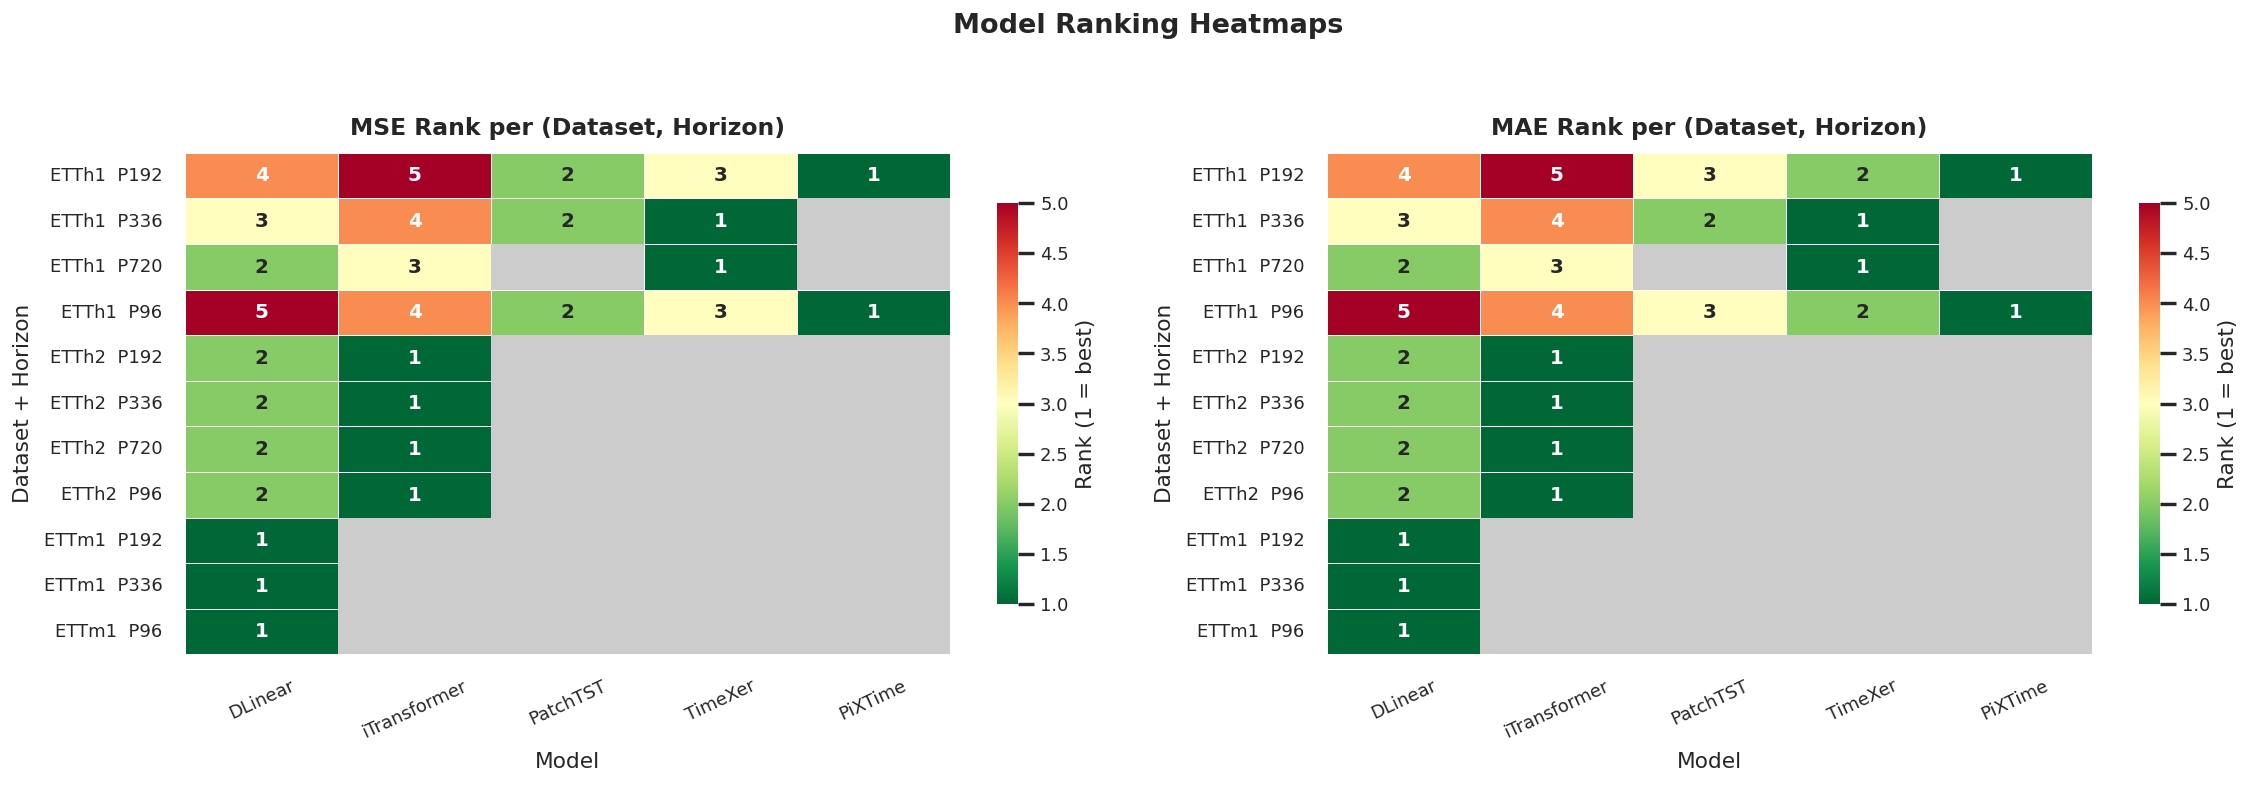

In [7]:
rank_df = df.copy()
rank_df['dataset_pred'] = rank_df['dataset'] + '  P' + rank_df['pred_len'].astype(str)
rank_df['mse_rank'] = rank_df.groupby(['dataset', 'pred_len'])['mse'].rank(method='min')
rank_df['mae_rank'] = rank_df.groupby(['dataset', 'pred_len'])['mae'].rank(method='min')

def make_rank_heat(metric_rank, ax, title):
    heat = (
        rank_df.pivot_table(
            index='dataset_pred', columns='model',
            values=metric_rank, aggfunc='min'
        )
    )
    # Keep MODEL_ORDER column order
    heat = heat[[m for m in MODEL_ORDER if m in heat.columns]]
    
    # Count participants per row to set vmax dynamically
    n_models_max = heat.notna().sum(axis=1).max()
    
    mask = heat.isna()
    sns.heatmap(
        heat, ax=ax,
        cmap='RdYlGn_r',
        linewidths=0.5,
        linecolor='white',
        annot=True, fmt='.0f',
        annot_kws={'size': 11, 'weight': 'bold'},
        vmin=1, vmax=n_models_max,
        mask=mask,
        cbar_kws={'label': 'Rank (1 = best)', 'shrink': 0.8},
    )
    # Grey out missing cells
    for (row, col), val in np.ndenumerate(heat.values):
        if np.isnan(val):
            ax.add_patch(plt.Rectangle((col, row), 1, 1, fill=True,
                                        color='#CCCCCC', lw=0))
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Model', labelpad=6)
    ax.set_ylabel('Dataset + Horizon', labelpad=6)
    ax.tick_params(axis='x', rotation=25)
    ax.tick_params(axis='y', rotation=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, max(5, 0.55 * rank_df['dataset_pred'].nunique())))
make_rank_heat('mse_rank', ax1, 'MSE Rank per (Dataset, Horizon)')
make_rank_heat('mae_rank', ax2, 'MAE Rank per (Dataset, Horizon)')
fig.suptitle('Model Ranking Heatmaps', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 5 — Aggregate Leaderboard (Composite Score)

**What this shows:** A single overall score per model, computed by:
1. For each `(dataset, horizon)` block, **min-max normalise** MSE and MAE to the [0, 1] range so that datasets with different scales don't dominate.
2. Average the normalised MSE and MAE into a **composite score** (equal weighting).
3. Average the composite score across all blocks that the model participated in.

A score of **0** means the model was best in every block; a score of **1** means it was worst in every block.

**Caveat:** Models that only ran on easier subsets may appear inflated. Always cross-reference with the coverage matrix (Section 1).

'       model  avg_mse  avg_mae  composite  n_runs\n     PiXTime 0.396692 0.408045   0.000000       2\n     TimeXer 0.451672 0.444786   0.232836       4\n    PatchTST 0.428243 0.430750   0.323024       3\niTransformer 0.428149 0.433118   0.485890       8\n     DLinear 0.476979 0.462224   0.647592      11'

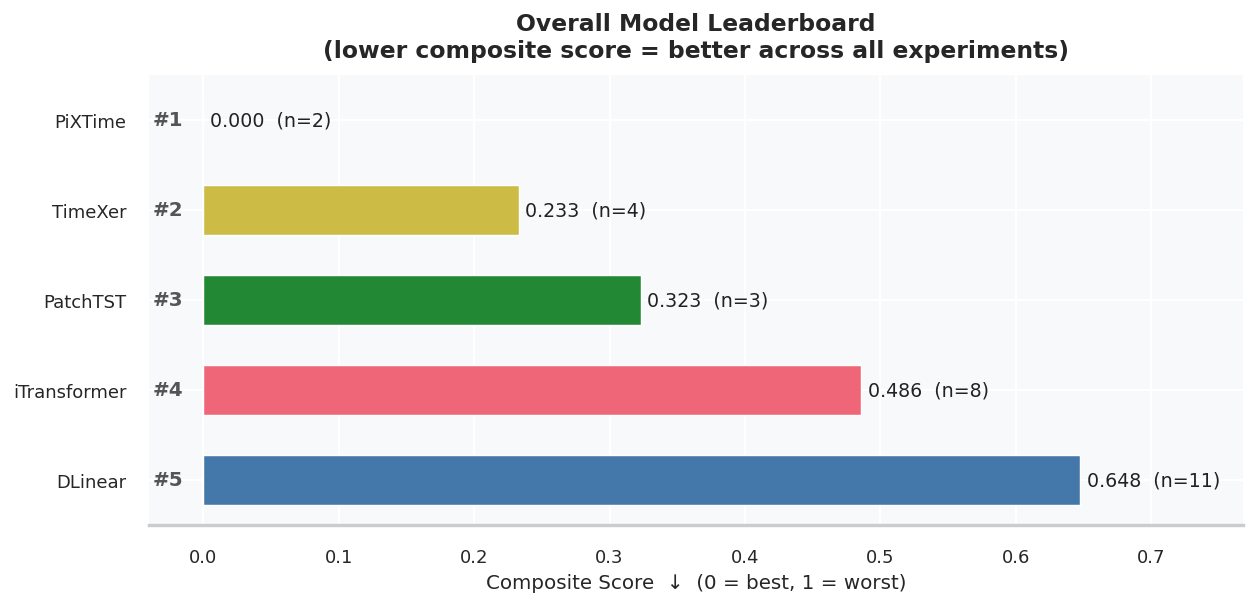

In [8]:
norm_df = df.copy()
for metric in ['mse', 'mae']:
    grp   = norm_df.groupby(['dataset', 'pred_len'])[metric]
    min_v = grp.transform('min')
    max_v = grp.transform('max')
    denom = (max_v - min_v).replace(0, 1)
    norm_df[f'{metric}_norm'] = (norm_df[metric] - min_v) / denom

norm_df['composite'] = 0.5 * norm_df['mse_norm'] + 0.5 * norm_df['mae_norm']

agg = (
    norm_df.groupby('model', observed=True)
           .agg(
               avg_mse=('mse', 'mean'),
               avg_mae=('mae', 'mean'),
               composite=('composite', 'mean'),
               n_runs=('composite', 'count'),
           )
           .sort_values('composite')
           .reset_index()
)
display(agg.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = [MODEL_COLORS.get(m, '#888') for m in agg['model']]
bars = ax.barh(agg['model'], agg['composite'], color=colors,
               edgecolor='white', linewidth=0.8, height=0.55)

# Value labels
for bar, val, n in zip(bars, agg['composite'], agg['n_runs']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}  (n={n})',
            va='center', fontsize=10.5, color='#222222')

# Rank badge on the left
for rank, (bar, model) in enumerate(zip(bars, agg['model']), 1):
    ax.text(-0.015, bar.get_y() + bar.get_height() / 2,
            f'#{rank}', va='center', ha='right',
            fontsize=11, fontweight='bold', color='#555555')

ax.set_xlim(-0.04, agg['composite'].max() + 0.12)
ax.set_xlabel('Composite Score  ↓  (0 = best, 1 = worst)', fontsize=11)
ax.set_ylabel('')
ax.set_title('Overall Model Leaderboard\n(lower composite score = better across all experiments)',
             fontsize=13, fontweight='bold', pad=10)
ax.set_facecolor('#F8F9FA')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(left=False)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 6 — Win Rate Analysis

**What this shows:** The percentage of `(dataset, horizon)` slots in which each model achieved **Rank 1** (strictly best MSE among models that competed in that slot).  
This is a head-to-head dominance metric — it is not affected by the absolute scale of errors, only by who came first.

**How to read it:**
- A **100% win rate** means the model was the best every single time it competed.
- Win rate is computed only over slots where the model has a result, so a model with fewer runs can still score 100% if it always won.
- Compare win rate with the composite score (Section 5): high win rate + low composite score = consistently and significantly the best model.

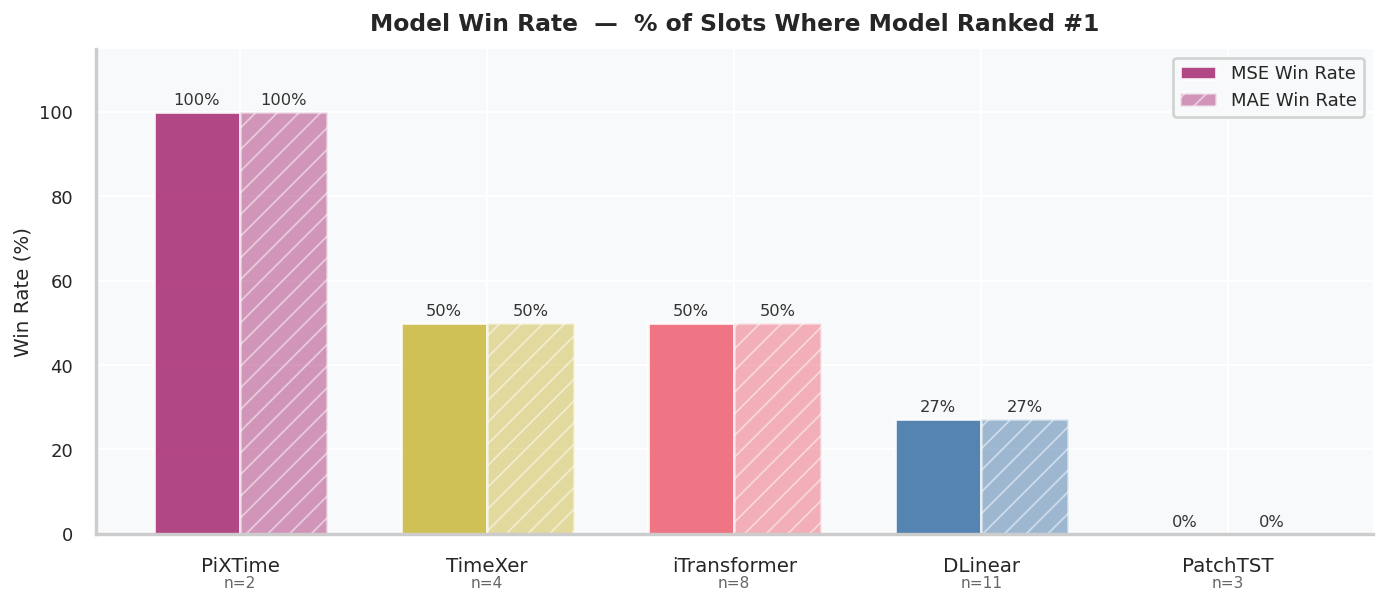

In [9]:
win_df = rank_df.copy()
win_df['mse_win'] = (win_df['mse_rank'] == 1).astype(int)
win_df['mae_win'] = (win_df['mae_rank'] == 1).astype(int)

win_agg = (
    win_df.groupby('model', observed=True)
          .agg(
              mse_wins=('mse_win', 'sum'),
              mae_wins=('mae_win', 'sum'),
              total=('mse_win', 'count'),
          )
          .reset_index()
)
win_agg['mse_win_rate'] = 100 * win_agg['mse_wins'] / win_agg['total']
win_agg['mae_win_rate'] = 100 * win_agg['mae_wins'] / win_agg['total']
win_agg = win_agg.sort_values('mse_win_rate', ascending=False).reset_index(drop=True)

x  = np.arange(len(win_agg))
w  = 0.35
fig, ax = plt.subplots(figsize=(11, 5))

bars1 = ax.bar(x - w/2, win_agg['mse_win_rate'], width=w,
               color=[MODEL_COLORS.get(m, '#888') for m in win_agg['model']],
               alpha=0.9, edgecolor='white', label='MSE Win Rate')
bars2 = ax.bar(x + w/2, win_agg['mae_win_rate'], width=w,
               color=[MODEL_COLORS.get(m, '#888') for m in win_agg['model']],
               alpha=0.5, edgecolor='white', hatch='//', label='MAE Win Rate')

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1,
            f'{h:.0f}%', ha='center', va='bottom', fontsize=9, color='#333333')

ax.set_xticks(x)
ax.set_xticklabels(win_agg['model'], fontsize=11)
ax.set_ylim(0, 115)
ax.set_ylabel('Win Rate (%)', fontsize=11)
ax.set_xlabel('')
ax.set_title('Model Win Rate  —  % of Slots Where Model Ranked #1',
             fontsize=13, fontweight='bold', pad=10)
ax.set_facecolor('#F8F9FA')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(framealpha=0.85)

# Annotate total slots
for i, (_, row) in enumerate(win_agg.iterrows()):
    ax.text(i, -10, f'n={int(row["total"])}', ha='center', va='top',
            fontsize=8.5, color='#666666')

plt.tight_layout()
plt.show()

---
## 7 — PiXTime vs Best Baseline: Percentage Improvement

**What this shows:** For every `(dataset, horizon)` slot where **PiXTime has a result**, this plot shows the **percentage improvement** of PiXTime's MSE (and MAE) over the best competing baseline in that same slot.

Formula:  
`improvement (%) = 100 × (baseline_best − PiXTime) / baseline_best`

**How to read it:**
- **Positive values (bars above zero)** → PiXTime is better than all baselines in that slot.
- **Negative values (bars below zero)** → PiXTime is worse than the best baseline in that slot.
- The number inside each bar is the exact improvement percentage.
- Each bar group is one `(dataset, horizon)` configuration.

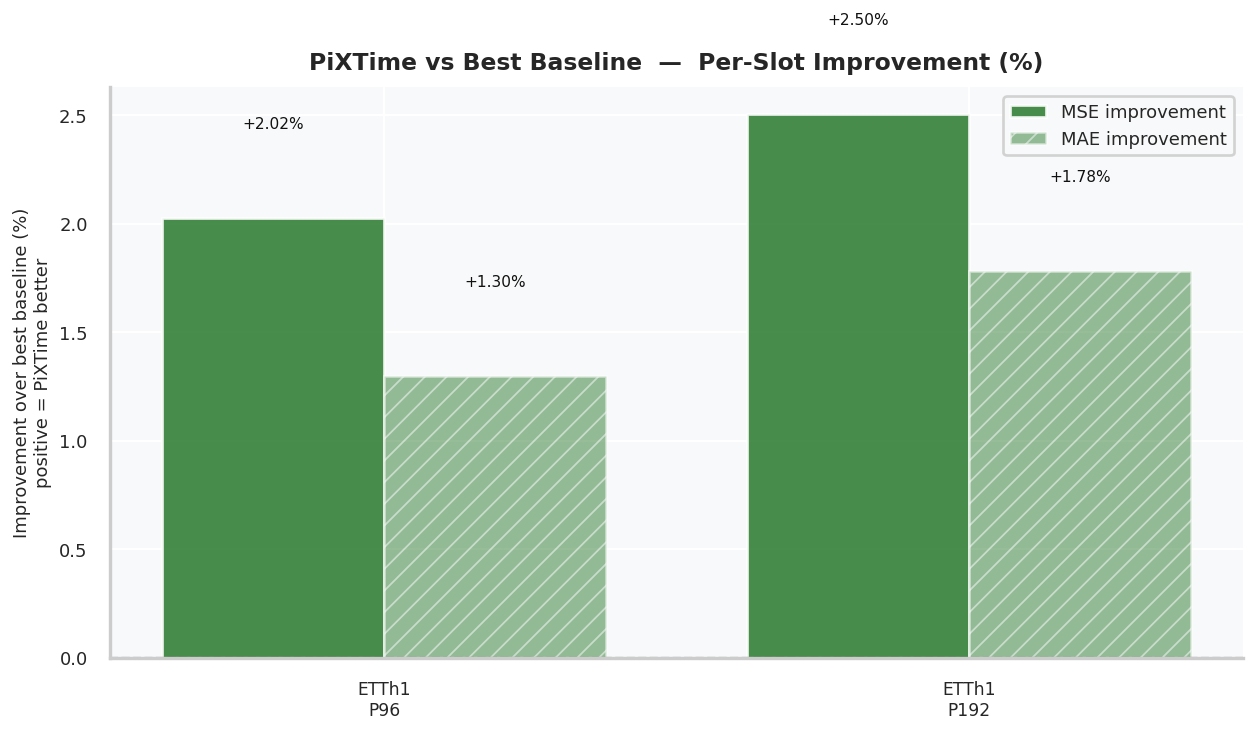

Average MSE improvement over best baseline: +2.26%
Average MAE improvement over best baseline: +1.54%


In [10]:
PIXT = 'PiXTime'
baselines = [m for m in models if m != PIXT]

if PIXT not in set(df['model']):
    print('PiXTime results not found — skipping improvement plot.')
else:
    pixt_df = df[df['model'] == PIXT][['dataset', 'pred_len', 'mse', 'mae']].copy()
    pixt_df.columns = ['dataset', 'pred_len', 'pixt_mse', 'pixt_mae']

    base_df = (
        df[df['model'].isin(baselines)]
          .groupby(['dataset', 'pred_len'], observed=True)
          .agg(best_mse=('mse', 'min'), best_mae=('mae', 'min'))
          .reset_index()
    )

    cmp = pixt_df.merge(base_df, on=['dataset', 'pred_len'])
    cmp['mse_impr'] = 100 * (cmp['best_mse'] - cmp['pixt_mse']) / cmp['best_mse']
    cmp['mae_impr'] = 100 * (cmp['best_mae'] - cmp['pixt_mae']) / cmp['best_mae']
    cmp['label'] = cmp['dataset'] + '\nP' + cmp['pred_len'].astype(str)
    cmp = cmp.sort_values(['dataset', 'pred_len']).reset_index(drop=True)

    x  = np.arange(len(cmp))
    w  = 0.38
    fig, ax = plt.subplots(figsize=(max(10, 1.6 * len(cmp)), 6))

    def bar_color(vals, pos_color, neg_color):
        return [pos_color if v >= 0 else neg_color for v in vals]

    bars1 = ax.bar(x - w/2, cmp['mse_impr'], width=w,
                   color=bar_color(cmp['mse_impr'], '#2E7D32', '#C62828'),
                   alpha=0.88, edgecolor='white', label='MSE improvement')
    bars2 = ax.bar(x + w/2, cmp['mae_impr'], width=w,
                   color=bar_color(cmp['mae_impr'], '#2E7D32', '#C62828'),
                   alpha=0.5, edgecolor='white', hatch='//', label='MAE improvement')

    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        offset = 0.4 if h >= 0 else -0.4
        ax.text(bar.get_x() + bar.get_width()/2,
                h + offset,
                f'{h:+.2f}%',
                ha='center',
                va='bottom' if h >= 0 else 'top',
                fontsize=8.5, color='#111111')

    ax.axhline(0, color='#333333', linewidth=1.2, linestyle='--', alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(cmp['label'], fontsize=9.5)
    ax.set_ylabel('Improvement over best baseline (%)\npositive = PiXTime better', fontsize=10)
    ax.set_title('PiXTime vs Best Baseline  —  Per-Slot Improvement (%)',
                 fontsize=13, fontweight='bold', pad=10)
    ax.set_facecolor('#F8F9FA')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(framealpha=0.85)
    plt.tight_layout()
    plt.show()

    avg_mse = cmp['mse_impr'].mean()
    avg_mae = cmp['mae_impr'].mean()
    print(f"Average MSE improvement over best baseline: {avg_mse:+.2f}%")
    print(f"Average MAE improvement over best baseline: {avg_mae:+.2f}%")

---
## Summary of Comparisons

| Section | Plot | Key Question Answered |
|---|---|---|
| **1 — Coverage Matrix** | Binary heatmap (green/red) | Are all experiments complete? Where are the gaps? |
| **2 — Direct Comparison** | Grouped bar charts (MSE & MAE) | Which model has the lowest raw error per dataset & horizon? |
| **3 — Horizon Degradation** | Line plots per dataset | Which model stays stable as the forecast horizon grows? |
| **4 — Rank Heatmaps** | Colour-coded rank grids | Is the winner consistent, or does it vary by setting? |
| **5 — Composite Leaderboard** | Horizontal bar chart | What is the overall winner across all settings? |
| **6 — Win Rate** | Grouped bars | How often does each model strictly rank #1? |
| **7 — PiXTime Improvement** | Diverging bar chart | By how much does PiXTime beat the best baseline, slot-by-slot? |

### Notes
- All plots regenerate automatically when new `.txt` result files are added under `evaluation/`.
- The benchmark grid is currently **partial** — fill remaining experiments to make aggregate scores fully comparable.
- Composite score and win rate are computed only over slots where the model has a result; check Section 1 before drawing strong conclusions.